In [5]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

In [6]:
TRAIN_DIR = "../data/train"
VAL_DIR = "../data/val"
TEST_DIR = "../data/test"

In [7]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 5216 files belonging to 2 classes.


In [8]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 16 files belonging to 2 classes.


In [9]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [10]:
for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 1)


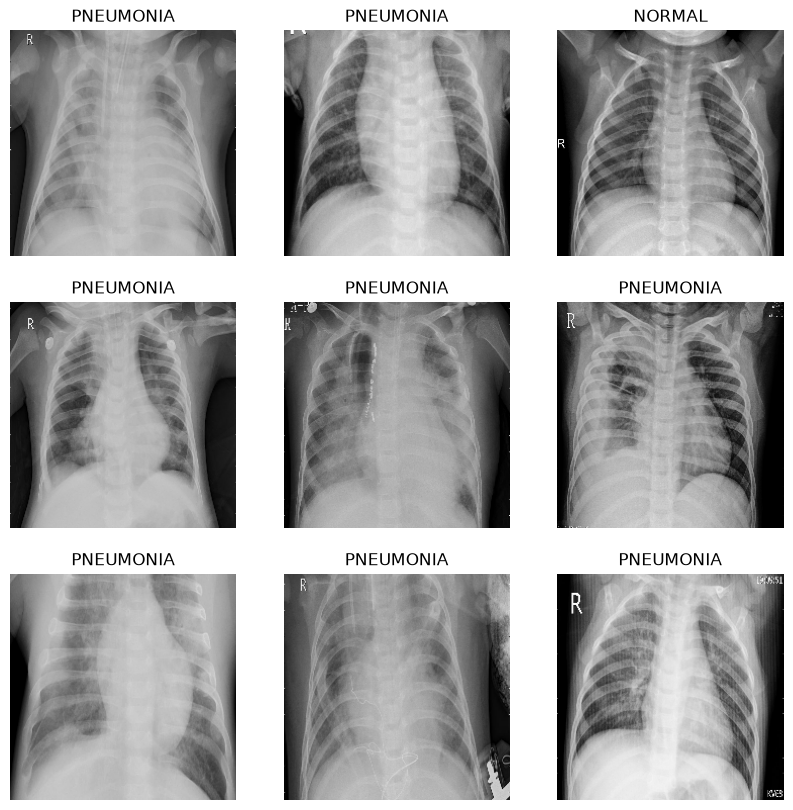

In [12]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            "PNEUMONIA"
            if labels[i] == 1
            else "NORMAL"
        )

        plt.axis("off")

plt.show()

In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [15]:
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [16]:
for images, labels in train_dataset.take(1):

    print("Minimum Pixel Value :", images.numpy().min())
    print("Maximum Pixel Value :", images.numpy().max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)